# Figure S14. Sylph vs propagate phage-to-host ratios

Species hosts use **genomovar-majority consensus** (highest count; alphabetical on ties), keyed by the species representative.

For Liang **unenriched** samples:
1. Compute sylph phage-to-host ratios from `True_cov` using the **cascade** method: predicted host species co-detection → genus singleton → family singleton.
2. Restrict **propagate** to prophages in `new_mq_plus_viruses.fna.gz`, then link `prophage-host_ratio` to sylph ratios via **strict RBH** on the vclust ANI table (primary), with a **best-gani** follow-up.
3. Compare paired ratios (scatter + correlation).


In [1]:
from pathlib import Path
import glob

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

pl.Config.set_tbl_rows(10)
plt.rcParams.update({'font.size': 14})

FIG4 = Path('../figure_4')
FIG1 = Path('../figure_1')
OUTS = FIG4 / 'activity_profiling/liang_enriched_results/2026-04-03_outputs'
SYLPH_DIR = OUTS / 'referenceanalyze/sylph'
PROP_DIR = OUTS / 'assemblyanalyze/propagate'
MQ_PLUS_FNA = OUTS / 'classify/new_mq_plus_viruses.fna.gz'
VCLUST_ANI = (
    OUTS / 'assemblyanalyze/vclust_new2all/new_mq_plus_viruses/new_mq_plus_viruses.ani.tsv'
)
GTDB_META = FIG4 / 'sylph_tax/gtdb_r226_metadata.tsv.gz'
PHIST_HOST = FIG1 / 'uhvdb_human_metag_results/uhvdb_2026-03-26-2/uhvdb_phisthost.tsv.gz'
CRISPR_HOST = FIG1 / 'uhvdb_human_metag_results/uhvdb_2026-03-26-2/uhvdb_crisprhost.tsv.gz'
SPECIES_INFO = FIG1 / 'uhvdb_human_metag_results/uhvdb_2026-03-26-2/uhvdb_species_info.tsv.gz'
GENOMOVAR_INFO = FIG1 / 'uhvdb_human_metag_results/uhvdb_2026-03-26-2/uhvdb_genomovars_info.tsv.gz'

print('SYLPH_DIR exists:', SYLPH_DIR.is_dir())
print('PROP_DIR exists:', PROP_DIR.is_dir())
print('MQ_PLUS_FNA exists:', MQ_PLUS_FNA.is_file())
print('VCLUST_ANI exists:', VCLUST_ANI.is_file())
print('SPECIES_INFO exists:', SPECIES_INFO.is_file())
print('GENOMOVAR_INFO exists:', GENOMOVAR_INFO.is_file())


SYLPH_DIR exists: True
PROP_DIR exists: True
MQ_PLUS_FNA exists: True
VCLUST_ANI exists: True
SPECIES_INFO exists: True
GENOMOVAR_INFO exists: True


## 1. Species-level hosts via genomovar consensus (PHIST + CRISPR)

Per-genomovar hosts are aggregated within each viral species: **highest count** wins (alphabetical if tied). Results are keyed by the species representative for sylph joins.

In [2]:
# Per-genomovar PHIST + CRISPR host calls
uhvdb_genomovar_host = (
    pl.read_csv(PHIST_HOST, separator='\t')[
        ['uhvdb_id', 'total_connections', 'rank', 'agreement', 'consensus_taxonomy']
    ]
    .join(
        pl.read_csv(CRISPR_HOST, separator='\t')[
            ['uhvdb_id', 'total_connections', 'rank', 'agreement', 'top_taxonomy']
        ],
        on=['uhvdb_id', 'rank'],
        how='full',
        suffix='_crispr',
    )
    .fill_null(0)
    .with_columns([
        pl.col('consensus_taxonomy').str.replace(r'^(s|g|f)__', ''),
    ])
    .with_columns([
        pl.when(pl.col('consensus_taxonomy') == pl.col('top_taxonomy'))
        .then(pl.col('consensus_taxonomy'))
        .when(
            (pl.col('total_connections') * pl.col('agreement'))
            >= (pl.col('total_connections_crispr') * pl.col('agreement_crispr'))
        )
        .then(pl.col('consensus_taxonomy'))
        .otherwise(pl.col('top_taxonomy'))
        .alias('final_taxonomy'),
        pl.when(pl.col('rank').is_not_null())
        .then(pl.col('rank'))
        .otherwise(pl.col('rank_crispr'))
        .alias('final_rank'),
        pl.when(pl.col('uhvdb_id').is_not_null())
        .then(pl.col('uhvdb_id'))
        .otherwise(pl.col('uhvdb_id_crispr'))
        .alias('final_id'),
    ])
    .group_by('final_id')
    .agg([
        pl.col('final_taxonomy').filter(pl.col('final_rank') == 'species').first().alias('final_species'),
        pl.col('final_taxonomy').filter(pl.col('final_rank') == 'genus').first().alias('final_genus'),
        pl.col('final_taxonomy').filter(pl.col('final_rank') == 'family').first().alias('final_family'),
    ])
    .rename({'final_id': 'uhvdb_id'})
)

species_info = pl.read_csv(SPECIES_INFO, separator='\t').select([
    'uhvdb_id',
    pl.col('cluster_id').alias('species_cluster_id'),
    pl.col('votu_rep').alias('species_rep'),
])
genomovar_reps = (
    pl.read_csv(GENOMOVAR_INFO, separator='\t')
    .filter(pl.col('uhvdb_id') == pl.col('votu_rep'))
    .select(pl.col('uhvdb_id').alias('genomovar_rep'))
    .unique()
)

gv_in_species = (
    species_info
    .join(genomovar_reps, left_on='uhvdb_id', right_on='genomovar_rep', how='inner')
    .join(uhvdb_genomovar_host, on='uhvdb_id', how='left')
    .rename({'uhvdb_id': 'genomovar_rep'})
)


def majority_host(df: pl.DataFrame, col: str) -> pl.DataFrame:
    """Highest-count label per species; alphabetical break on ties."""
    return (
        df
        .filter(pl.col(col).is_not_null())
        .group_by(['species_cluster_id', col])
        .agg(pl.len().alias('n'))
        .sort(['species_cluster_id', 'n', col], descending=[False, True, False])
        .unique('species_cluster_id', maintain_order=True)
        .select(['species_cluster_id', col])
    )


species_consensus = (
    species_info
    .select(['species_cluster_id', 'species_rep'])
    .unique()
    .join(majority_host(gv_in_species, 'final_species'), on='species_cluster_id', how='left')
    .join(majority_host(gv_in_species, 'final_genus'), on='species_cluster_id', how='left')
    .join(majority_host(gv_in_species, 'final_family'), on='species_cluster_id', how='left')
)

# Key by species rep (same role as previous uhvdb_combinedhost for sylph joins)
uhvdb_combinedhost = species_consensus.select([
    pl.col('species_rep').alias('uhvdb_id'),
    'final_species',
    'final_genus',
    'final_family',
])

rep_only = (
    species_consensus
    .select(['species_rep'])
    .join(uhvdb_genomovar_host, left_on='species_rep', right_on='uhvdb_id', how='left')
    .rename({
        'final_species': 'rep_final_species',
        'final_genus': 'rep_final_genus',
    })
)
qc = species_consensus.join(rep_only, on='species_rep', how='left')
both_sp = qc.filter(pl.col('final_species').is_not_null() & pl.col('rep_final_species').is_not_null())
print('species clusters:', uhvdb_combinedhost.height)
print('with consensus host species:', uhvdb_combinedhost.filter(pl.col('final_species').is_not_null()).height)
print('with consensus host genus:', uhvdb_combinedhost.filter(pl.col('final_genus').is_not_null()).height)
print(
    'agree with species-rep (species host):',
    int((both_sp['final_species'] == both_sp['rep_final_species']).sum()),
    '/',
    both_sp.height,
    f"({100 * (both_sp['final_species'] == both_sp['rep_final_species']).mean():.2f}%)",
)
uhvdb_combinedhost.head()


species clusters: 199442
with consensus host species: 115481
with consensus host genus: 176701
agree with species-rep (species host): 112258 / 112668 (99.64%)


uhvdb_id,final_species,final_genus,final_family
str,str,str,str
"""UHVDB-75462""",null,null,"""Erysipelotrichaceae"""
"""UHVDB-423396""","""Oligella urethralis""","""Oligella""","""Burkholderiaceae"""
"""UHVDB-373891""",null,"""Prevotella""","""Bacteroidaceae"""
"""UHVDB-87574""","""Sellimonas intestinalis""","""Sellimonas""","""Lachnospiraceae"""
"""UHVDB-234062""",null,"""Eubacterium""","""Eubacteriaceae"""


## 2. Load sylph profiles + GTDB taxonomy

In [3]:
gtdb_meta = (
    pl.read_csv(
        GTDB_META,
        separator='\t',
        has_header=False,
        new_columns=['accession', 'lineage'],
    )
    .with_columns([
        pl.col('lineage').str.extract(r'f__([^;]+)', 1).alias('family'),
        pl.col('lineage').str.extract(r'g__([^;]+)', 1).alias('genus'),
        pl.col('lineage').str.extract(r's__([^;]+)', 1).alias('species'),
    ])
    .unique('accession')
)

sylph_lst = []
for path in sorted(glob.glob(str(SYLPH_DIR / 'liang_*_unenriched' / 'liang_*_unenriched.profile.tsv'))):
    sample_id = Path(path).name.replace('.profile.tsv', '')
    if '_enriched' in sample_id and '_unenriched' not in sample_id:
        continue
    df = (
        pl.read_csv(path, separator='\t')
        .with_columns([
            pl.lit(sample_id).alias('sample_id'),
            pl.col('True_cov').cast(pl.Float64),
            pl.col('Genome_file').str.extract(r'(GC[AF]_\d+\.\d+)', 1).alias('accession'),
            pl.when(pl.col('Genome_file').str.contains('uhvdb'))
            .then(pl.lit('phage'))
            .when(pl.col('Genome_file').str.contains('gtdb'))
            .then(pl.lit('bacteria'))
            .otherwise(pl.lit('other'))
            .alias('row_type'),
        ])
    )
    sylph_lst.append(df)

sylph_df = pl.concat(sylph_lst)
print('samples:', sylph_df['sample_id'].n_unique(), 'rows:', sylph_df.height)
print(sylph_df['row_type'].value_counts())

phage_sylph = (
    sylph_df
    .filter(pl.col('row_type') == 'phage')
    .select([
        'sample_id',
        pl.col('Contig_name').alias('uhvdb_id'),
        pl.col('True_cov').alias('phage_True_cov'),
    ])
)

bac_sylph = (
    sylph_df
    .filter(pl.col('row_type') == 'bacteria')
    .join(gtdb_meta, on='accession', how='left')
    .filter(pl.col('species').is_not_null())
    .group_by(['sample_id', 'species', 'genus', 'family'])
    .agg(pl.col('True_cov').max().alias('host_True_cov'))
)

print('phage detections:', phage_sylph.height, 'bacterial species detections:', bac_sylph.height)
bac_sylph.head()

samples: 38 rows: 5267
shape: (2, 2)
┌──────────┬───────┐
│ row_type ┆ count │
│ ---      ┆ ---   │
│ str      ┆ u32   │
╞══════════╪═══════╡
│ bacteria ┆ 1586  │
│ phage    ┆ 3681  │
└──────────┴───────┘
phage detections: 3681 bacterial species detections: 1586


sample_id,species,genus,family,host_True_cov
str,str,str,str,f64
"""liang_3454_unenriched""","""Nanogingivalis sp934717805""","""Nanogingivalis""","""Nanogingivalaceae""",0.377
"""liang_3594_unenriched""","""Bifidobacterium longum""","""Bifidobacterium""","""Bifidobacteriaceae""",47.199
"""liang_392_unenriched""","""Veillonella sp900550175""","""Veillonella""","""Veillonellaceae""",0.774
"""liang_261_unenriched""","""Lancefieldella sp015258765""","""Lancefieldella""","""Atopobiaceae""",0.448
"""liang_105_unenriched""","""Anaerostipes caccae""","""Anaerostipes""","""Lachnospiraceae""",0.325


## 3. Sylph phage-to-host ratios — cascade

Strict priority (each tier only for viruses not already matched):

- **species_codetected**: predicted species host is co-detected → phage `True_cov` / host species `True_cov`
- **genus_singleton**: exactly one co-detected species in the predicted host genus
- **family_singleton**: exactly one co-detected species in the predicted host family

Stored as `sylph_ratio_cascade_df` and aliased as primary `sylph_ratio_df` for downstream pairing / plots.


In [4]:
phage_with_host = (
    phage_sylph
    .join(
        uhvdb_combinedhost.select(['uhvdb_id', 'final_species', 'final_genus', 'final_family']),
        on='uhvdb_id',
        how='left',
    )
)

# 1) predicted host species co-detected
species_hits = (
    phage_with_host
    .filter(pl.col('final_species').is_not_null())
    .join(
        bac_sylph.select(['sample_id', 'species', 'host_True_cov']),
        left_on=['sample_id', 'final_species'],
        right_on=['sample_id', 'species'],
        how='inner',
    )
    .with_columns([
        pl.lit('species_codetected').alias('ratio_rule'),
        pl.col('final_species').alias('matched_host_species'),
    ])
)
matched_keys = species_hits.select(['sample_id', 'uhvdb_id']).unique()

# 2) singleton species within predicted host genus
genus_singleton = (
    bac_sylph
    .filter(pl.col('genus').is_not_null())
    .group_by(['sample_id', 'genus'])
    .agg([
        pl.len().alias('n_species'),
        pl.col('species').first().alias('species'),
        pl.col('host_True_cov').first().alias('host_True_cov'),
    ])
    .filter(pl.col('n_species') == 1)
)
genus_hits = (
    phage_with_host
    .join(matched_keys, on=['sample_id', 'uhvdb_id'], how='anti')
    .filter(pl.col('final_genus').is_not_null())
    .join(
        genus_singleton.select(['sample_id', 'genus', 'species', 'host_True_cov']),
        left_on=['sample_id', 'final_genus'],
        right_on=['sample_id', 'genus'],
        how='inner',
    )
    .with_columns([
        pl.lit('genus_singleton').alias('ratio_rule'),
        pl.col('species').alias('matched_host_species'),
    ])
)
matched_keys = pl.concat([
    matched_keys,
    genus_hits.select(['sample_id', 'uhvdb_id']),
]).unique()

# 3) singleton species within predicted host family
family_singleton = (
    bac_sylph
    .filter(pl.col('family').is_not_null())
    .group_by(['sample_id', 'family'])
    .agg([
        pl.len().alias('n_species'),
        pl.col('species').first().alias('species'),
        pl.col('host_True_cov').first().alias('host_True_cov'),
    ])
    .filter(pl.col('n_species') == 1)
)
family_hits = (
    phage_with_host
    .join(matched_keys, on=['sample_id', 'uhvdb_id'], how='anti')
    .filter(pl.col('final_family').is_not_null())
    .join(
        family_singleton.select(['sample_id', 'family', 'species', 'host_True_cov']),
        left_on=['sample_id', 'final_family'],
        right_on=['sample_id', 'family'],
        how='inner',
    )
    .with_columns([
        pl.lit('family_singleton').alias('ratio_rule'),
        pl.col('species').alias('matched_host_species'),
    ])
)

ratio_cols = [
    'sample_id', 'uhvdb_id', 'phage_True_cov', 'host_True_cov',
    'final_species', 'final_genus', 'final_family',
    'matched_host_species', 'ratio_rule',
]
sylph_ratio_cascade_df = (
    pl.concat([
        species_hits.select(ratio_cols),
        genus_hits.select(ratio_cols),
        family_hits.select(ratio_cols),
    ])
    .with_columns([
        (pl.col('phage_True_cov') / pl.col('host_True_cov')).alias('sylph_phage_host_ratio'),
    ])
    .filter(pl.col('host_True_cov') > 0)
    .unique(subset=['sample_id', 'uhvdb_id'], keep='first')
)

print('Cascade PTH rows:', sylph_ratio_cascade_df.height)
print(sylph_ratio_cascade_df['ratio_rule'].value_counts())

# Primary sylph PTH for downstream RBH pairing / plots
sylph_ratio_df = sylph_ratio_cascade_df
sylph_ratio_df.head()


Cascade PTH rows: 2596
shape: (3, 2)
┌────────────────────┬───────┐
│ ratio_rule         ┆ count │
│ ---                ┆ ---   │
│ str                ┆ u32   │
╞════════════════════╪═══════╡
│ genus_singleton    ┆ 225   │
│ species_codetected ┆ 2333  │
│ family_singleton   ┆ 38    │
└────────────────────┴───────┘


sample_id,uhvdb_id,phage_True_cov,host_True_cov,final_species,final_genus,final_family,matched_host_species,ratio_rule,sylph_phage_host_ratio
str,str,f64,f64,str,str,str,str,str,f64
"""liang_392_unenriched""","""UHVDB-84133""",46.099,47.586,"""Phocaeicola vulgatus""","""Phocaeicola""","""Bacteroidaceae""","""Phocaeicola vulgatus""","""species_codetected""",0.968751
"""liang_261_unenriched""","""UHVDB-76743""",0.49,0.626,"""Flavonifractor plautii""","""Flavonifractor""","""Oscillospiraceae""","""Flavonifractor plautii""","""species_codetected""",0.782748
"""liang_4284_unenriched""","""UHVDB-46853""",1.281,0.494,"""Hungatella hathewayi""","""Hungatella""","""Lachnospiraceae""","""Hungatella hathewayi""","""species_codetected""",2.593117
"""liang_275_unenriched""","""UHVDB-91470""",0.397,0.289,"""Clostridium_AQ innocuum""","""Clostridium_AQ""","""Erysipelotrichaceae""","""Clostridium_AQ innocuum""","""species_codetected""",1.373702
"""liang_3451_unenriched""","""UHVDB-41918""",8.81,10.519,"""Enterococcus faecalis""","""Enterococcus""","""Enterococcaceae""","""Enterococcus faecalis""","""species_codetected""",0.837532


## 3b. Primary PTH = cascade

Closest-to-1 and union(min) are no longer used. Downstream analyses consume `sylph_ratio_df` (= cascade).


In [5]:
# Cascade is the sole primary PTH (set in §3).
assert 'sylph_ratio_df' in dir()
print('Primary cascade PTH rows:', sylph_ratio_df.height)
print(sylph_ratio_df['ratio_rule'].value_counts())
sylph_ratio_df.head()


Primary cascade PTH rows: 2596
shape: (3, 2)
┌────────────────────┬───────┐
│ ratio_rule         ┆ count │
│ ---                ┆ ---   │
│ str                ┆ u32   │
╞════════════════════╪═══════╡
│ species_codetected ┆ 2333  │
│ family_singleton   ┆ 38    │
│ genus_singleton    ┆ 225   │
└────────────────────┴───────┘


sample_id,uhvdb_id,phage_True_cov,host_True_cov,final_species,final_genus,final_family,matched_host_species,ratio_rule,sylph_phage_host_ratio
str,str,f64,f64,str,str,str,str,str,f64
"""liang_392_unenriched""","""UHVDB-84133""",46.099,47.586,"""Phocaeicola vulgatus""","""Phocaeicola""","""Bacteroidaceae""","""Phocaeicola vulgatus""","""species_codetected""",0.968751
"""liang_261_unenriched""","""UHVDB-76743""",0.49,0.626,"""Flavonifractor plautii""","""Flavonifractor""","""Oscillospiraceae""","""Flavonifractor plautii""","""species_codetected""",0.782748
"""liang_4284_unenriched""","""UHVDB-46853""",1.281,0.494,"""Hungatella hathewayi""","""Hungatella""","""Lachnospiraceae""","""Hungatella hathewayi""","""species_codetected""",2.593117
"""liang_275_unenriched""","""UHVDB-91470""",0.397,0.289,"""Clostridium_AQ innocuum""","""Clostridium_AQ""","""Erysipelotrichaceae""","""Clostridium_AQ innocuum""","""species_codetected""",1.373702
"""liang_3451_unenriched""","""UHVDB-41918""",8.81,10.519,"""Enterococcus faecalis""","""Enterococcus""","""Enterococcaceae""","""Enterococcus faecalis""","""species_codetected""",0.837532


## 4. Load propagate ratios (MQ+ viruses only)

Keep only propagate calls whose `prophage` ID is present in `new_mq_plus_viruses.fna.gz` (exact header match).


In [6]:
propagate_lst = []
for path in sorted(glob.glob(str(PROP_DIR / 'liang_*_unenriched' / 'liang_*_unenriched.propagate.tsv.gz'))):
    sample_id = Path(path).name.replace('.propagate.tsv.gz', '')
    df = (
        pl.read_csv(
            path,
            separator='\t',
            null_values=['NA'],
            columns=[
                'prophage', 'host', 'active', 'CohenD', 'prophage-host_ratio',
                'prophage_mean_cov', 'host_mean_cov',
            ],
        )
        .with_columns([
            pl.lit(sample_id).alias('sample_id'),
            pl.col('prophage').cast(pl.String),
            pl.col('prophage-host_ratio').cast(pl.Float64),
            pl.col('CohenD').cast(pl.Float64),
        ])
    )
    if df.height > 0:
        propagate_lst.append(df)

propagate_df_all = pl.concat(propagate_lst)

# Restrict to viruses in the MQ+ FASTA (same set used for vclust / BLAST)
import gzip

def read_fna_ids(path: Path) -> set[str]:
    open_fn = gzip.open if str(path).endswith('.gz') else open
    with open_fn(path, 'rt') as fh:
        return {line[1:].strip().split()[0] for line in fh if line.startswith('>')}

mq_plus_ids = read_fna_ids(MQ_PLUS_FNA)
propagate_df = propagate_df_all.filter(pl.col('prophage').is_in(list(mq_plus_ids)))
print(
    'propagate rows (all):', propagate_df_all.height,
    '| MQ+ filtered:', propagate_df.height,
    f'({100 * propagate_df.height / max(propagate_df_all.height, 1):.1f}%)',
)
print('samples:', propagate_df['sample_id'].n_unique(), '| MQ+ ids:', len(mq_plus_ids))
propagate_df.head()

propagate rows (all): 757 | MQ+ filtered: 366 (48.3%)
samples: 38 | MQ+ ids: 1430


prophage,host,active,CohenD,prophage-host_ratio,prophage_mean_cov,host_mean_cov,sample_id
str,str,str,f64,f64,f64,f64,str
"""liang_100_unenriched_k251_2933…","""liang_100_unenriched_k251_2933…","""dormant""",0.032337,0.98902,17.799896,17.9975,"""liang_100_unenriched"""
"""liang_100_unenriched_k251_1244…","""liang_100_unenriched_k251_1244""","""dormant""",0.330143,1.124135,19.373136,17.233811,"""liang_100_unenriched"""
"""liang_100_unenriched_k251_1358…","""liang_100_unenriched_k251_1358""","""dormant""",0.098912,0.968022,16.551579,17.098351,"""liang_100_unenriched"""
"""liang_100_unenriched_k251_1642…","""liang_100_unenriched_k251_1642""","""dormant""",0.205843,1.0713,21.4108,19.985804,"""liang_100_unenriched"""
"""liang_100_unenriched_k251_1815…","""liang_100_unenriched_k251_1815…","""dormant""",0.119871,1.030229,55.091201,53.474729,"""liang_100_unenriched"""


## 5. Orient vclust ANI pairs (assembled ↔ UHVDB)

In [7]:
vclust_raw = pl.read_csv(VCLUST_ANI, separator='\t')

# Normalize to assembled_id (liang_*) vs uhvdb_id (UHVDB-*)
vclust_oriented = (
    pl.concat([
        vclust_raw
        .filter(
            pl.col('query').str.starts_with('liang_')
            & pl.col('reference').str.starts_with('UHVDB-')
        )
        .select([
            pl.col('query').alias('assembled_id'),
            pl.col('reference').alias('uhvdb_id'),
            'gani', 'ani', 'qcov', 'rcov',
        ]),
        vclust_raw
        .filter(
            pl.col('query').str.starts_with('UHVDB-')
            & pl.col('reference').str.starts_with('liang_')
        )
        .select([
            pl.col('reference').alias('assembled_id'),
            pl.col('query').alias('uhvdb_id'),
            'gani',
            'ani',
            # swap coverages when orientation flips
            pl.col('rcov').alias('qcov'),
            pl.col('qcov').alias('rcov'),
        ]),
    ])
    .filter(pl.col('assembled_id').str.contains('_unenriched_'))
    .with_columns([
        pl.col('assembled_id').str.split('_k').list.first().alias('sample_id'),
        (pl.col('ani') * pl.col('qcov')).alias('match_q'),
        (pl.col('ani') * pl.col('rcov')).alias('match_t'),
    ])
    # Prefer the row with higher gani if both orientations present
    .sort('gani', descending=True)
    .unique(['assembled_id', 'uhvdb_id'], maintain_order=True)
)

# Restrict to UHVDB IDs sylph-detected in the same sample
sylph_detected = phage_sylph.select(['sample_id', 'uhvdb_id']).unique()
vclust_hits = (
    vclust_oriented
    .join(sylph_detected, on=['sample_id', 'uhvdb_id'], how='inner')
)

print('oriented unenriched pairs:', vclust_oriented.height)
print('after sylph co-detection filter:', vclust_hits.height)
vclust_hits.head()

oriented unenriched pairs: 121518
after sylph co-detection filter: 1422


assembled_id,uhvdb_id,gani,ani,qcov,rcov,sample_id,match_q,match_t
str,str,f64,f64,f64,f64,str,f64,f64
"""liang_4001_unenriched_k251_520…","""UHVDB-64294""",1.0,1.0,1.0,1.0,"""liang_4001_unenriched""",1.0,1.0
"""liang_4014_unenriched_k251_165…","""UHVDB-64303""",1.0,1.0,1.0,1.0,"""liang_4014_unenriched""",1.0,1.0
"""liang_126_unenriched_k251_2669…","""UHVDB-64357""",1.0,1.0,1.0,0.891853,"""liang_126_unenriched""",1.0,0.891853
"""liang_101_unenriched_k251_2497…","""UHVDB-90368""",1.0,1.0,1.0,0.540741,"""liang_101_unenriched""",1.0,0.540741
"""liang_392_unenriched_k251_5903…","""UHVDB-64601""",1.0,1.0,1.0,1.0,"""liang_392_unenriched""",1.0,1.0


## 6. Strict RBH linking (primary)

Per sample: best assembled hit by `match_q = ani * qcov`, best UHVDB hit by `match_t = ani * rcov`; keep reciprocal pairs.


In [8]:
def build_rbh(vclust_hits: pl.DataFrame) -> pl.DataFrame:
    rows = []
    for sample_id in vclust_hits['sample_id'].unique().to_list():
        links = vclust_hits.filter(pl.col('sample_id') == sample_id)
        best_for_assembled = (
            links.sort('match_q', descending=True).unique('assembled_id', maintain_order=True)
        )
        best_for_uhvdb = (
            links
            .sort('match_t', descending=True)
            .unique('uhvdb_id', maintain_order=True)
            .select(['assembled_id', 'uhvdb_id'])
        )
        rbh = best_for_assembled.join(
            best_for_uhvdb, on=['assembled_id', 'uhvdb_id'], how='inner'
        )
        rows.append(rbh)
    return pl.concat(rows) if rows else pl.DataFrame()


rbh_links = build_rbh(vclust_hits)
print('RBH pairs:', rbh_links.height)


def join_propagate_and_sylph(
    links: pl.DataFrame,
    link_label: str,
    ratio_df: pl.DataFrame | None = None,
) -> pl.DataFrame:
    """Join linking table to propagate (exact prophage ID) and sylph ratios."""
    if ratio_df is None:
        ratio_df = sylph_ratio_df
    # Exact match on prophage ID (includes |provirus_... when present in vclust)
    exact = (
        links
        .join(
            propagate_df,
            left_on=['assembled_id', 'sample_id'],
            right_on=['prophage', 'sample_id'],
            how='inner',
        )
        .with_columns(pl.lit('exact_prophage').alias('propagate_join'))
    )

    # Fallback: contig without |provirus suffix (only for links not already matched)
    unmatched = links.join(
        exact.select(['assembled_id', 'sample_id']).unique(),
        on=['assembled_id', 'sample_id'],
        how='anti',
    )
    prop_by_contig = (
        propagate_df
        .with_columns(
            pl.col('prophage').str.split('|provirus').list.first().alias('contig_id')
        )
    )
    fallback = (
        unmatched
        .with_columns(
            pl.col('assembled_id').str.split('|provirus').list.first().alias('contig_id')
        )
        .join(prop_by_contig, on=['contig_id', 'sample_id'], how='inner')
        .with_columns(pl.lit('contig_fallback').alias('propagate_join'))
    )

    paired = (
        pl.concat([exact, fallback], how='diagonal_relaxed')
        .join(
            ratio_df,
            on=['sample_id', 'uhvdb_id'],
            how='inner',
        )
        .with_columns(pl.lit(link_label).alias('link_method'))
        .filter(
            pl.col('sylph_phage_host_ratio').is_not_null()
            & pl.col('prophage-host_ratio').is_not_null()
            & (pl.col('sylph_phage_host_ratio') > 0)
            & (pl.col('prophage-host_ratio') > 0)
        )
    )
    return paired


rbh_paired = join_propagate_and_sylph(rbh_links, 'rbh')
print('RBH paired with both ratios:', rbh_paired.height)
print(rbh_paired['propagate_join'].value_counts())
print(rbh_paired['ratio_rule'].value_counts())
rbh_paired.select([
    'sample_id', 'assembled_id', 'uhvdb_id', 'prophage',
    'sylph_phage_host_ratio', 'prophage-host_ratio',
    'ratio_rule', 'match_q', 'match_t', 'gani',
]).head()

def attach_propagate(links: pl.DataFrame) -> pl.DataFrame:
    """Left-join propagate onto RBH/best-gani links (exact, then contig fallback)."""
    exact = (
        links
        .join(
            propagate_df,
            left_on=['assembled_id', 'sample_id'],
            right_on=['prophage', 'sample_id'],
            how='left',
        )
        .with_columns(
            pl.when(pl.col('prophage-host_ratio').is_not_null())
            .then(pl.lit('exact_prophage'))
            .otherwise(pl.lit(None))
            .alias('propagate_join')
        )
    )
    have_exact = exact.filter(pl.col('prophage-host_ratio').is_not_null())
    need_fallback = exact.filter(pl.col('prophage-host_ratio').is_null()).select(links.columns)

    prop_by_contig = (
        propagate_df
        .with_columns(
            pl.col('prophage').str.split('|provirus').list.first().alias('contig_id')
        )
    )
    fallback = (
        need_fallback
        .with_columns(
            pl.col('assembled_id').str.split('|provirus').list.first().alias('contig_id')
        )
        .join(prop_by_contig, on=['contig_id', 'sample_id'], how='left')
        .with_columns(
            pl.when(pl.col('prophage-host_ratio').is_not_null())
            .then(pl.lit('contig_fallback'))
            .otherwise(pl.lit('no_propagate'))
            .alias('propagate_join')
        )
    )
    return pl.concat([have_exact, fallback], how='diagonal_relaxed')


def join_either_ratio_optional(
    links: pl.DataFrame,
    link_label: str,
    ratio_df: pl.DataFrame | None = None,
) -> pl.DataFrame:
    """RBH links with sylph and/or propagate ratios (missing side left null)."""
    if ratio_df is None:
        ratio_df = sylph_ratio_df

    # Sylph present (propagate optional)
    with_sylph = (
        attach_propagate(
            links.join(ratio_df, on=['sample_id', 'uhvdb_id'], how='inner')
            .filter(
                pl.col('sylph_phage_host_ratio').is_not_null()
                & (pl.col('sylph_phage_host_ratio') > 0)
            )
        )
        .with_columns(pl.lit('has_sylph').alias('sylph_status'))
    )

    # Propagate present (sylph optional / missing)
    with_prop = (
        attach_propagate(links)
        .filter(
            pl.col('prophage-host_ratio').is_not_null()
            & (pl.col('prophage-host_ratio') > 0)
        )
        .join(ratio_df, on=['sample_id', 'uhvdb_id'], how='left')
    )
    prop_only = (
        with_prop
        .join(
            with_sylph.select(['sample_id', 'uhvdb_id', 'assembled_id']).unique(),
            on=['sample_id', 'uhvdb_id', 'assembled_id'],
            how='anti',
        )
        .with_columns([
            pl.lit('no_sylph').alias('sylph_status'),
            pl.when(pl.col('sylph_phage_host_ratio').is_null() | (pl.col('sylph_phage_host_ratio') <= 0))
            .then(pl.lit(None))
            .otherwise(pl.col('sylph_phage_host_ratio'))
            .alias('sylph_phage_host_ratio'),
        ])
    )

    paired = (
        pl.concat([with_sylph, prop_only], how='diagonal_relaxed')
        .with_columns(pl.lit(link_label).alias('link_method'))
    )
    return paired


def build_all_pth_scatter_df(
    ratio_df: pl.DataFrame | None = None,
) -> pl.DataFrame:
    """All sylph PTH detections and all propagate ratios (no RBH required).

    - RBH-paired points keep both ratios (+ match scores)
    - Sylph-only PTH -> propagate=0
    - Propagate-only -> sylph=0
    """
    if ratio_df is None:
        ratio_df = sylph_ratio_df

    paired = (
        join_propagate_and_sylph(rbh_links, 'rbh', ratio_df)
        .with_columns(pl.lit('both').alias('point_type'))
    )
    paired_keys_sylph = paired.select(['sample_id', 'uhvdb_id']).unique()
    paired_prophages = (
        paired
        .select(['sample_id', 'assembled_id'])
        .unique()
        .rename({'assembled_id': 'prophage'})
    )

    sylph_only = (
        ratio_df
        .join(paired_keys_sylph, on=['sample_id', 'uhvdb_id'], how='anti')
        .filter(
            pl.col('sylph_phage_host_ratio').is_not_null()
            & (pl.col('sylph_phage_host_ratio') > 0)
        )
        .with_columns([
            pl.lit(0.0).alias('prophage-host_ratio'),
            pl.lit(None).cast(pl.Float64).alias('match_t'),
            pl.lit(None).cast(pl.Float64).alias('match_q'),
            pl.lit(None).cast(pl.Float64).alias('gani'),
            pl.lit('sylph_only').alias('point_type'),
            pl.lit('all_sylph_prop').alias('link_method'),
        ])
    )

    prop_only = (
        propagate_df
        .join(paired_prophages, on=['sample_id', 'prophage'], how='anti')
        .filter(
            pl.col('prophage-host_ratio').is_not_null()
            & (pl.col('prophage-host_ratio') > 0)
        )
        .with_columns([
            pl.lit(0.0).alias('sylph_phage_host_ratio'),
            pl.lit(None).cast(pl.Float64).alias('match_t'),
            pl.lit(None).cast(pl.Float64).alias('match_q'),
            pl.lit(None).cast(pl.Float64).alias('gani'),
            pl.lit('propagate_only').alias('point_type'),
            pl.lit('all_sylph_prop').alias('link_method'),
            pl.col('prophage').alias('assembled_id'),
            pl.lit(None).cast(pl.String).alias('uhvdb_id'),
        ])
    )

    keep_paired = [
        c for c in [
            'sample_id', 'uhvdb_id', 'assembled_id', 'prophage',
            'sylph_phage_host_ratio', 'prophage-host_ratio',
            'match_t', 'match_q', 'gani', 'point_type', 'link_method',
            'ratio_rule', 'phage_True_cov', 'host_True_cov',
        ]
        if c in paired.columns
    ]
    return pl.concat(
        [
            paired.select(keep_paired),
            sylph_only.select([c for c in keep_paired if c in sylph_only.columns]),
            prop_only.select([c for c in keep_paired if c in prop_only.columns]),
        ],
        how='diagonal_relaxed',
    )


rbh_paired_incl_missing_prop = build_all_pth_scatter_df()
n_missing_prop = rbh_paired_incl_missing_prop.filter(pl.col('point_type') == 'sylph_only').height
n_missing_sylph = rbh_paired_incl_missing_prop.filter(pl.col('point_type') == 'propagate_only').height
n_both = rbh_paired_incl_missing_prop.filter(pl.col('point_type') == 'both').height
print(
    'All sylph PTH + all propagate (no RBH required):',
    rbh_paired_incl_missing_prop.height,
    '| both(RBH):', n_both,
    '| sylph_only:', n_missing_prop,
    '| propagate_only:', n_missing_sylph,
)


RBH pairs: 587
RBH paired with both ratios: 272
shape: (1, 2)
┌────────────────┬───────┐
│ propagate_join ┆ count │
│ ---            ┆ ---   │
│ str            ┆ u32   │
╞════════════════╪═══════╡
│ exact_prophage ┆ 272   │
└────────────────┴───────┘
shape: (3, 2)
┌────────────────────┬───────┐
│ ratio_rule         ┆ count │
│ ---                ┆ ---   │
│ str                ┆ u32   │
╞════════════════════╪═══════╡
│ species_codetected ┆ 232   │
│ genus_singleton    ┆ 34    │
│ family_singleton   ┆ 6     │
└────────────────────┴───────┘
All sylph PTH + all propagate (no RBH required): 2690 | both(RBH): 272 | sylph_only: 2324 | propagate_only: 94


## 7. Best-gani follow-up (secondary)

Per sample, among hits to sylph-detected UHVDB IDs: best `gani` per assembled query (no reciprocity).

In [9]:
best_gani_links = (
    vclust_hits
    .sort('gani', descending=True)
    .unique(['sample_id', 'assembled_id'], maintain_order=True)
)
print('best-gani pairs:', best_gani_links.height)

best_gani_paired = join_propagate_and_sylph(best_gani_links, 'best_gani')
print('best-gani paired with both ratios:', best_gani_paired.height)
print(best_gani_paired['propagate_join'].value_counts())

# Overlap of paired (sample_id, assembled_id, uhvdb_id)
rbh_keys = rbh_paired.select(['sample_id', 'assembled_id', 'uhvdb_id']).unique()
gani_keys = best_gani_paired.select(['sample_id', 'assembled_id', 'uhvdb_id']).unique()
overlap = rbh_keys.join(gani_keys, on=['sample_id', 'assembled_id', 'uhvdb_id'], how='inner')
print('RBH paired n:', rbh_keys.height)
print('best-gani paired n:', gani_keys.height)
print('shared link triples:', overlap.height)

best-gani pairs: 608
best-gani paired with both ratios: 278
shape: (1, 2)
┌────────────────┬───────┐
│ propagate_join ┆ count │
│ ---            ┆ ---   │
│ str            ┆ u32   │
╞════════════════╪═══════╡
│ exact_prophage ┆ 278   │
└────────────────┴───────┘
RBH paired n: 272
best-gani paired n: 278
shared link triples: 270


## 8. Comparison plots


wrote sylph_vs_propagate_rbh.png


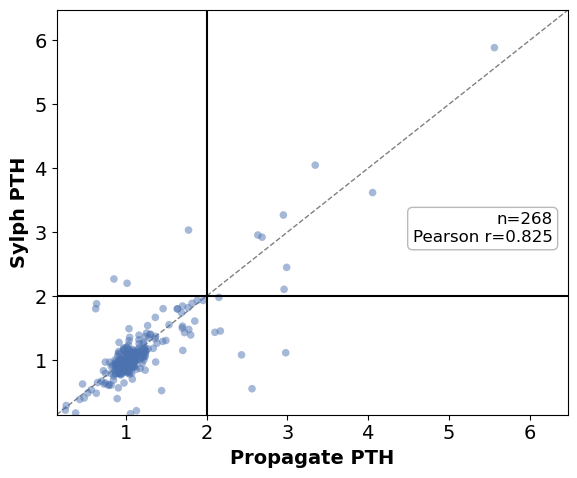

shape: (1, 6)
┌─────────────┬─────┬───────────┬────────────┬────────────┬────────────┐
│ link_method ┆ n   ┆ pearson_r ┆ pearson_p  ┆ spearman_r ┆ spearman_p │
│ ---         ┆ --- ┆ ---       ┆ ---        ┆ ---        ┆ ---        │
│ str         ┆ i64 ┆ f64       ┆ f64        ┆ f64        ┆ f64        │
╞═════════════╪═════╪═══════════╪════════════╪════════════╪════════════╡
│ rbh         ┆ 268 ┆ 0.825352  ┆ 5.4761e-68 ┆ 0.651027   ┆ 1.0616e-33 │
└─────────────┴─────┴───────────┴────────────┴────────────┴────────────┘


In [12]:
def correlation_stats(df: pl.DataFrame) -> dict:
    x = df['prophage-host_ratio'].to_numpy()
    y = df['sylph_phage_host_ratio'].to_numpy()
    pr = pearsonr(x, y)
    sr = spearmanr(x, y)
    return {
        'n': len(x),
        'pearson_r': float(pr.statistic),
        'pearson_p': float(pr.pvalue),
        'spearman_r': float(sr.statistic),
        'spearman_p': float(sr.pvalue),
    }


def plot_ratio_scatter(
    df: pl.DataFrame,
    title: str,
    out_path: Path | None = None,
    include_missing_propagate: bool = False,
):
    LOG_FLOOR = 0.1  # display floor for 0/missing values on log axes

    if include_missing_propagate:
        plot_df = df.with_columns([
            pl.col('prophage-host_ratio').fill_null(0.0).clip(lower_bound=0.0),
            pl.col('sylph_phage_host_ratio').fill_null(0.0).clip(lower_bound=0.0),
            pl.col('match_t').fill_null(0.0),
        ])
        # RBH-paired stats only for both PTH <= 10
        corr_df = plot_df.filter(
            (pl.col('prophage-host_ratio') > 0)
            & (pl.col('prophage-host_ratio') <= 10)
            & (pl.col('sylph_phage_host_ratio') > 0)
            & (pl.col('sylph_phage_host_ratio') <= 10)
        )
        if 'point_type' in plot_df.columns:
            n_missing_prop = plot_df.filter(pl.col('point_type') == 'sylph_only').height
            n_missing_sylph = plot_df.filter(pl.col('point_type') == 'propagate_only').height
        else:
            n_missing_prop = plot_df.filter(pl.col('prophage-host_ratio') <= 0).height
            n_missing_sylph = plot_df.filter(pl.col('sylph_phage_host_ratio') <= 0).height
    else:
        # RBH stats/plot: both PTH values in (0, 10]
        plot_df = df.filter(
            pl.col('sylph_phage_host_ratio').is_not_null()
            & (pl.col('sylph_phage_host_ratio') > 0)
            & (pl.col('sylph_phage_host_ratio') <= 10)
            & pl.col('prophage-host_ratio').is_not_null()
            & (pl.col('prophage-host_ratio') > 0)
            & (pl.col('prophage-host_ratio') <= 10)
        )
        corr_df = plot_df
        n_missing_prop = 0
        n_missing_sylph = 0

    stats = correlation_stats(corr_df) if corr_df.height >= 2 else {
        'n': corr_df.height, 'pearson_r': float('nan'), 'pearson_p': float('nan'),
        'spearman_r': float('nan'), 'spearman_p': float('nan'),
    }

    # Floor zeros so unpaired points remain visible on log-log axes
    plot_df = plot_df.with_columns([
        pl.when(pl.col('prophage-host_ratio') <= 0)
        .then(pl.lit(LOG_FLOOR))
        .otherwise(pl.col('prophage-host_ratio'))
        .alias('prophage-host_ratio'),
        pl.when(pl.col('sylph_phage_host_ratio') <= 0)
        .then(pl.lit(LOG_FLOOR))
        .otherwise(pl.col('sylph_phage_host_ratio'))
        .alias('sylph_phage_host_ratio'),
    ])
    pdf = plot_df.select(['prophage-host_ratio', 'sylph_phage_host_ratio']).to_pandas()

    xmax = max(pdf['prophage-host_ratio'].max(), pdf['sylph_phage_host_ratio'].max()) * 1.1
    xmin = LOG_FLOOR if include_missing_propagate else min(
        pdf['prophage-host_ratio'].min(), pdf['sylph_phage_host_ratio'].min()
    ) * 0.9
    lims = [xmin, xmax]

    fig, ax = plt.subplots(figsize=(6, 5))
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    ax.scatter(
        pdf['prophage-host_ratio'],
        pdf['sylph_phage_host_ratio'],
        color='#4C72B0',
        alpha=0.5,
        s=30,
        edgecolors='none',
    )
    ax.plot(lims, lims, ls='--', color='grey', lw=1, zorder=0)
    ax.axvline(2, color='black', lw=1.5, zorder=1)
    ax.axhline(2, color='black', lw=1.5, zorder=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Propagate PTH', fontweight='bold', fontsize=14)
    ax.set_ylabel('Sylph PTH', fontweight='bold', fontsize=14)

    if include_missing_propagate:
        stats_txt = (
            f"n={stats['n']}\n"
            f"Pearson r={stats['pearson_r']:.3f}\n"
            f"miss prop={n_missing_prop}\n"
            f"miss sylph={n_missing_sylph}"
        )
    else:
        stats_txt = f"n={stats['n']}\nPearson r={stats['pearson_r']:.3f}"
    ax.text(
        0.97, 0.5, stats_txt,
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=12,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='0.7', alpha=0.9),
    )

    fig.tight_layout()
    if out_path is not None:
        fig.savefig(out_path, dpi=200, bbox_inches='tight')
        print('wrote', out_path)
    plt.show()
    return stats


rbh_stats = plot_ratio_scatter(
    rbh_paired,
    'RBH linking (primary)',
    Path('sylph_vs_propagate_rbh.png'),
)
# rbh_stats_incl_missing = plot_ratio_scatter(
#     rbh_paired_incl_missing_prop,
#     'All sylph PTH + all propagate (no RBH required)',
#     Path('sylph_vs_propagate_rbh_incl_missing_prop.png'),
#     include_missing_propagate=True,
# )

summary = pl.DataFrame([
    {'link_method': 'rbh', **rbh_stats},
])
summary.write_csv('sylph_vs_propagate_correlation_summary.tsv', separator='\t')
print(summary)

## 9. Counts: sylph detections / PTH vs MQ+ propagate PTH

Unique UHVDB species detected by sylph, with a **cascade** sylph PTH, and propagate PTH calls restricted to MQ+ viruses.


shape: (3, 4)
┌────────────────────┬─────────┬──────────────┬──────────────┐
│ method             ┆ n_count ┆ n_detections ┆ count_label  │
│ ---                ┆ ---     ┆ ---          ┆ ---          │
│ str                ┆ i64     ┆ i64          ┆ str          │
╞════════════════════╪═════════╪══════════════╪══════════════╡
│ Total virus        ┆ 2139    ┆ 3681         ┆ unique UHVDB │
│ species detections ┆         ┆              ┆              │
│ Sylph PTH          ┆ 1584    ┆ 2596         ┆ unique UHVDB │
│ Propagate PTH      ┆ 366     ┆ 366          ┆ PTH calls    │
└────────────────────┴─────────┴──────────────┴──────────────┘
wrote virus_species_pth_ratio_counts.png


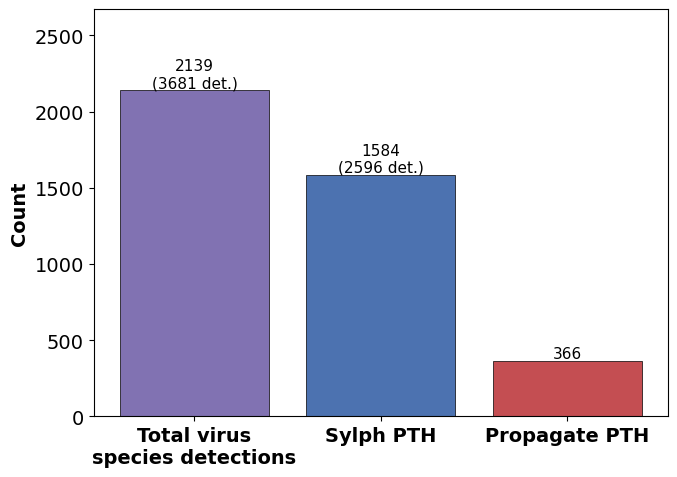

In [11]:
prop_pth = (
    propagate_df
    .filter(
        pl.col('prophage-host_ratio').is_not_null()
        & (pl.col('prophage-host_ratio') > 0)
    )
)
total_detections = phage_sylph.select(['sample_id', 'uhvdb_id']).unique()
sylph_pth = sylph_ratio_df.select(['sample_id', 'uhvdb_id']).unique()

count_df = pl.DataFrame({
    'method': [
        'Total virus\nspecies detections',
        'Sylph PTH',
        'Propagate PTH',
    ],
    'n_count': [
        total_detections['uhvdb_id'].n_unique(),
        sylph_pth['uhvdb_id'].n_unique(),
        prop_pth.height,
    ],
    'n_detections': [
        total_detections.height,
        sylph_pth.height,
        prop_pth.height,
    ],
    'count_label': [
        'unique UHVDB',
        'unique UHVDB',
        'PTH calls',
    ],
})
print(count_df)

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(count_df.height)
bars = ax.bar(
    x,
    count_df['n_count'].to_list(),
    color=['#8172B2', '#4C72B0', '#C44E52'],
    edgecolor='black',
    linewidth=0.5,
)
ax.set_xticks(x)
ax.set_xticklabels(count_df['method'].to_list(), fontweight='bold', fontsize=14)
ax.set_ylabel('Count', fontweight='bold', fontsize=14)
# ax.set_title('Virus species / PTH ratio counts', fontweight='bold', fontsize=14)
for bar, n, nd, lab in zip(
    bars,
    count_df['n_count'],
    count_df['n_detections'],
    count_df['count_label'],
):
    if lab == 'PTH calls':
        label = f'{n}'
    else:
        label = f'{n}\n({nd} det.)'
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        label,
        ha='center', va='bottom', fontsize=11,
    )
ax.set_ylim(0, count_df['n_count'].max() * 1.25)
fig.tight_layout()
fig.savefig('virus_species_pth_ratio_counts.png', dpi=200, bbox_inches='tight')
print('wrote virus_species_pth_ratio_counts.png')
plt.show()